    Gabriella Castelari Gonçalves - 14755082
    Isabela Müller Martins Rocha - 14579732
    Thaís Laura Anício Andrade - 14608765


In [1]:
# Criação da função RandomFailFinos e estabelecimento de alguns parâmetros

import numpy as np
import matplotlib.pyplot as plt

def GeraRede(nx,ny,CH,CV):
    nv = nx*ny
    nc = (nx-1)*ny + (ny-1)*nx
    
    coord = np.zeros(shape=(nv,2))

    for i in range(nx):
      for j in range(ny):
        ig = i + j*nx
        coord[ig,0] = i
        coord[ig,1] = j

    conec = np.zeros(shape=(nc,2), dtype=int)
    C = np.zeros(nc)
    
    # Loop sobre canos horizontais
    for j in range(ny):
        for i in range(nx-1):
          k = j*(nx-1) + i
          conec[k,0] = j*nx + i
          conec[k,1] = j*nx + i+1
          C[k] = CH

    # Loop sobre canos verticais
    for i in range(nx):
      for j in range(ny-1):
          k = (nx-1)*ny + j*nx + i
          conec[k,0] = i + j*nx
          conec[k,1] = i + (j+1)*nx
          C[k] = CV

    return nv, nc, conec, C, coord

def Assembly(conec, C):
    nv = np.max(conec) + 1  
    nc = len(conec[:,0]) 
    A = np.zeros(shape=(nv, nv))
    for k in range(nc):
        n1 = conec[k,0]
        n2 = conec[k,1]
        A[n1,n1] = A[n1,n1] + C[k]
        A[n2,n2] = A[n2,n2] + C[k]
        A[n1,n2] = - C[k]
        A[n2,n1] = - C[k]
    return A

def SolveNetwork(conec, natm, nB, QB, C):
    Atilde = Assembly(conec, C)
    Atilde[natm, :] = 0
    Atilde[natm, natm] = 1
    nv = len(Atilde[0,:])
    b = np.zeros(shape=(nv,1))
    b[nB,0] = QB
    pressure = np.linalg.solve(Atilde, b)
    return pressure



def RandomFailFinos(C, p0, Centup):
    Cnew = np.copy(C)
    nc = len(C)
    for k in range(nc):
        if(Cnew[k] == 2.0):
            x = np.random.rand()
            if(x < p0): 
                Cnew[k] = Centup
    return Cnew

CH = 2.0
CV = 2.0
nx, ny = 10, 10
Centup = 0.2
p0 = 0.1       
nv, nc, conec, C, coord = GeraRede(nx, ny , CH, CV)

lst = [0, 1, 2, 30, 31, 32, 93, 103, 113]
C[lst] = 20.0
nB = 0
natm = nv -1
QB = 10

P_lim = 12

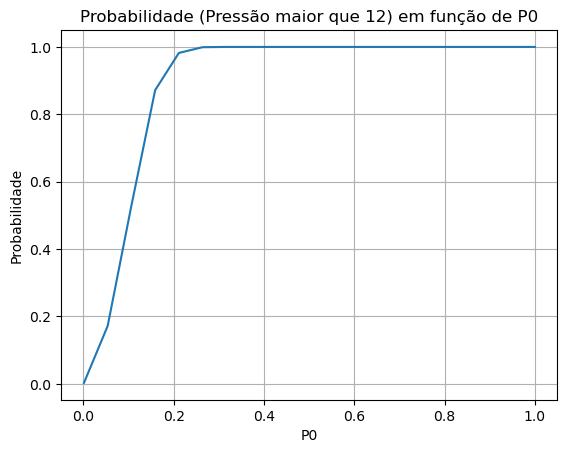

In [14]:
# Probabilidade em função de p0

realizacoes = 5000
probabilidades = np.linspace(0.001,1, 20)
lst_p0 = []
lst_prob1 =[]
qtd = 1
    
for j in probabilidades:
    casos = 0
    for i in range(realizacoes): 
        Cnew = RandomFailFinos(C, j, Centup)
        pressao = SolveNetwork(conec, natm, nB, QB, Cnew)
        pmax = np.max(pressao)
        if pmax > P_lim:
            casos += 1
    lst_p0.append(j)
    lst_prob1.append(casos/realizacoes)   

    
    
plt.plot(lst_p0, lst_prob1)
plt.grid()
plt.xlabel('P0')
plt.ylabel('Probabilidade')
plt.title('Probabilidade (Pressão maior que 12) em função de P0')
plt.show()

In [15]:
import numpy as np
import pandas as pd

realizacoes = 5000
probabilidades = np.linspace(0.001, 1, 20)
lst_p0 = []
lst_prob1 = []

for j in probabilidades:
    casos = 0
    for i in range(realizacoes):
        Cnew = RandomFailFinos(C, j, Centup)
        pressao = SolveNetwork(conec, natm, nB, QB, Cnew)
        pmax = np.max(pressao)
        if pmax > P_lim:
            casos += 1
    probabilidade = casos / realizacoes
    lst_p0.append(j)
    lst_prob1.append(probabilidade)

# Criar DataFrame
data = {'P0': lst_p0, 'Probabilidade': lst_prob1}
df = pd.DataFrame(data)

# Exibir tabela
print(df)


          P0  Probabilidade
0   0.001000         0.0016
1   0.053579         0.1742
2   0.106158         0.5314
3   0.158737         0.8628
4   0.211316         0.9842
5   0.263895         0.9992
6   0.316474         0.9998
7   0.369053         1.0000
8   0.421632         1.0000
9   0.474211         1.0000
10  0.526789         1.0000
11  0.579368         1.0000
12  0.631947         1.0000
13  0.684526         1.0000
14  0.737105         1.0000
15  0.789684         1.0000
16  0.842263         1.0000
17  0.894842         1.0000
18  0.947421         1.0000
19  1.000000         1.0000


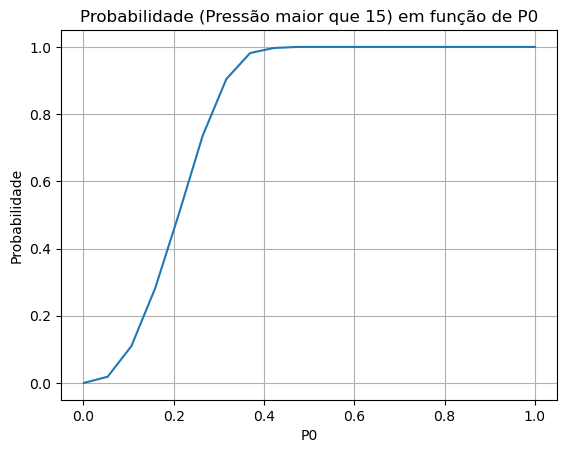

In [17]:
# Probabilidade em função de p0

realizacoes = 5000
probabilidades = np.linspace(0.001,1, 20)
lst_p0 = []
lst_prob1 =[]
qtd = 1
    
for j in probabilidades:
    casos = 0
    for i in range(realizacoes): 
        Cnew = RandomFailFinos(C, j, Centup)
        pressao = SolveNetwork(conec, natm, nB, QB, Cnew)
        pmax = np.max(pressao)
        if pmax > 15:
            casos += 1
    lst_p0.append(j)
    lst_prob1.append(casos/realizacoes)   

    
    
plt.plot(lst_p0, lst_prob1)
plt.grid()
plt.xlabel('P0')
plt.ylabel('Probabilidade')
plt.title('Probabilidade (Pressão maior que 15) em função de P0')
plt.show()

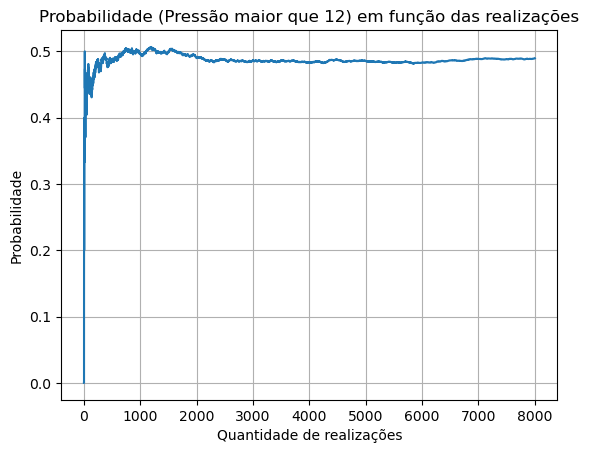

In [13]:
# Probabilidade em função da quantidade de realizações
# Primeiro gráfico 

casos = 0
realizacoes = 8000 
lst_N = []
lst_prob2 = []
for i in range(realizacoes): 
    Cnew = RandomFailFinos(C, p0, Centup)
    pressao = SolveNetwork(conec, natm, nB, QB, Cnew)
    pmax = np.max(pressao)
    if pmax > P_lim:
        casos += 1
        
    lst_N.append(i+1)
    lst_prob2.append(casos/(i+1))

plt.plot(lst_N, lst_prob2)
plt.grid()
plt.xlabel('Quantidade de realizações')
plt.ylabel('Probabilidade')
plt.title('Probabilidade (Pressão maior que 12) em função das realizações')
plt.show()

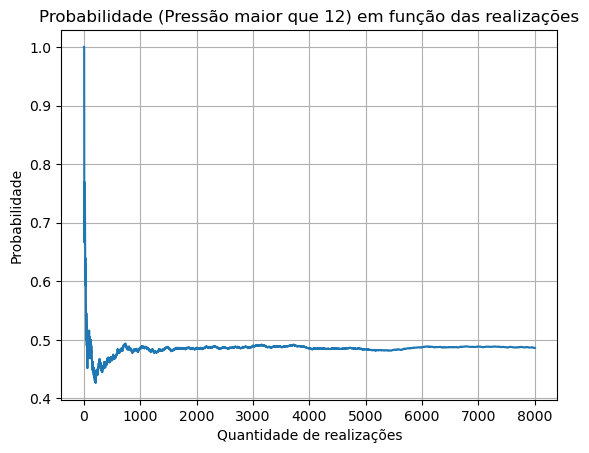

In [9]:
# Probabilidade em função da quantidade de realizações
# Segundo gráfico

casos = 0
realizacoes = 8000 #até 10.000
lst_N = []
lst_prob2 = []
for i in range(realizacoes): 
    Cnew = RandomFailFinos(C, p0, Centup)
    pressao = SolveNetwork(conec, natm, nB, QB, Cnew)
    pmax = np.max(pressao)
    if pmax > P_lim:
        casos += 1
        
    lst_N.append(i+1)
    lst_prob2.append(casos/(i+1))

plt.plot(lst_N, lst_prob2)
plt.grid()
plt.xlabel('Quantidade de realizações')
plt.ylabel('Probabilidade')
plt.title('Probabilidade (Pressão maior que 12) em função das realizações')
plt.show()

### Conclusões

    É possível observar que a tabela e o gráfico, os quais mostram a relação entre a probabilidade da pressão da rede ultrapassar o limite 12 e a probabilidade de um cano fino entupir, indicam uma estabilidade na ordenada logo quando a abscissa se torna maior do que 0.2: 100% dos casos ultrapassam a pressão máxima nesses pontos. Isso mostra a dependência instrínseca dessas variáveis, ou seja, é garantido que a rede não consegue distribuir essa pressão acumulada quando mais de 20% dos casos finos são comprometidos. É importante ressaltar, assim, que se o limite de pressão (P_lim) fosse diferente de 12, os resultados provavelmente seriam diferentes. Tome o gráfico em sequência da tabela: com esses dados, a ordenada se estabiliza em 1.0 a partir de um valor p0 maior (aproximadamente 0.4). Isso revela a necessidade do estabelecimento de parâmetros corretos para não comprometer toda a rede.
    
    Também é interessante notar que, apesar de alguns erros aleatórios quando as realizações são pequenas (no primeiro gráfico, os primeiros casos não ultrapassam o limite, enquanto, no segundo, sim), a probabilidade da rede ultrapassar a pressão máxima para p0 = 0.1 se mantém constante (perto de 0.5) mesmo que se varie a quantidade de realizações. Uma das hipóteses seria que o sistema é bem definido no sentido de não sofrer grandes variações mesmo com números aleatórios.